In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv("bike_train.csv")
test = pd.read_csv("bike_test.csv")

In [3]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


In [4]:
train.shape

(10450, 12)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 979.8+ KB


In [6]:
train.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


**Exploratory Data Analysis (EDA)**



Q1: Examine dataset size, missing values, and feature types.

**[ANSWER]: **

**Training data shape:** (10450, 12) - 10450 rows/examples and 12 features/columns.

**No missing values.**

**Target variable is count** - total number of bike rentals

**Categorical**
season, holiday, workingday, weather

**Numerical**
casual, registered,temp,atemp,humidity,windspeed,count

**Feature Engineering Required:**

1.Might need to remove features - casual and registered because casual + registered = count. These features might cause data leakage by indirectly revealing the target answer to the Model.

2. **datetime** - Object/String datatype but needs feature engineering. Need to extract year, month, day, hour to make it understandable to the Linear Regression algorithm. Also, need to perform cyclic transformation to ensure that time is read as cyclic feature instead of linear.

**Q2. Visualize relationships between key features and the target variable (count).**

In [7]:
import matplotlib.pyplot as plt
import seaborn as sb

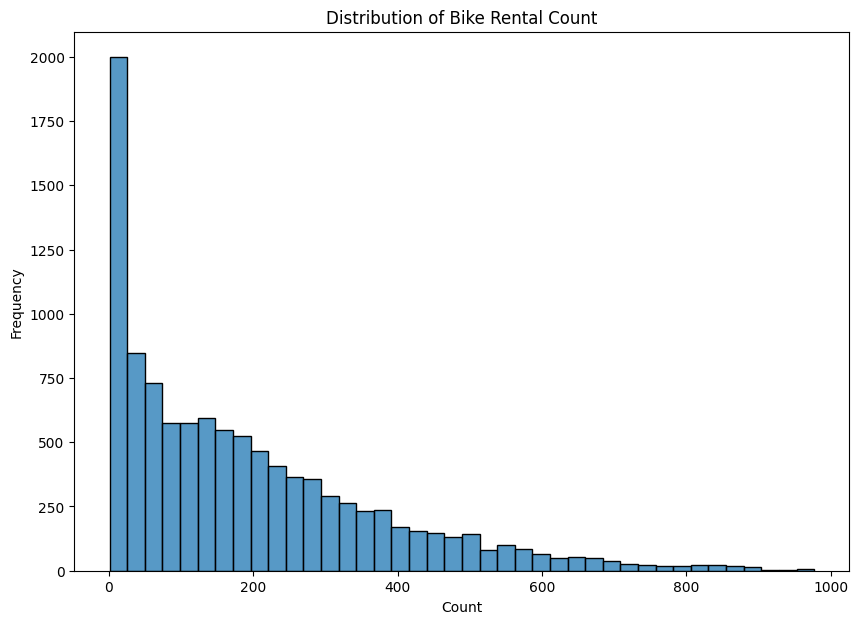

In [8]:
plt.figure(figsize=(10,7))

sb.histplot(train['count'], bins=40)
plt.title("Distribution of Bike Rental Count")
plt.xlabel("Count")
plt.ylabel("Frequency")

plt.show()

[ANSWERS]:

1. There is higher frequency of low rental values - especially between Count = 0-200.

2. High rentals are very rare/less frequent.

3. Right-skewed/positively skewed due to above mentioned reasons.

4. Below Graphs explain the relationship of each feature with the target.

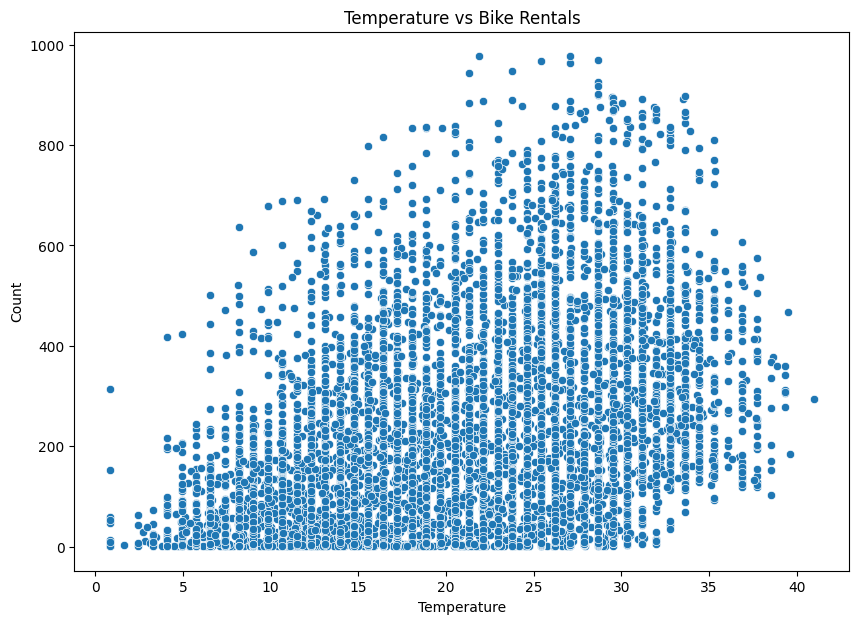

In [9]:
plt.figure(figsize=(10,7))

sb.scatterplot(x='temp', y='count', data=train)

plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Count")

plt.show()

**1. Relationship of Temperature with Count**

a) Bike Rentals are low/decreasing when the temperature is extremely high or low.

b) Bike rentals are high during comfortable temperatures between 20-30.

c) Relationship is not linear - Bike rentals are not increasing/decreasing linearly with temperature.

d) Due to above reasons, Plynomial Regression will be required.


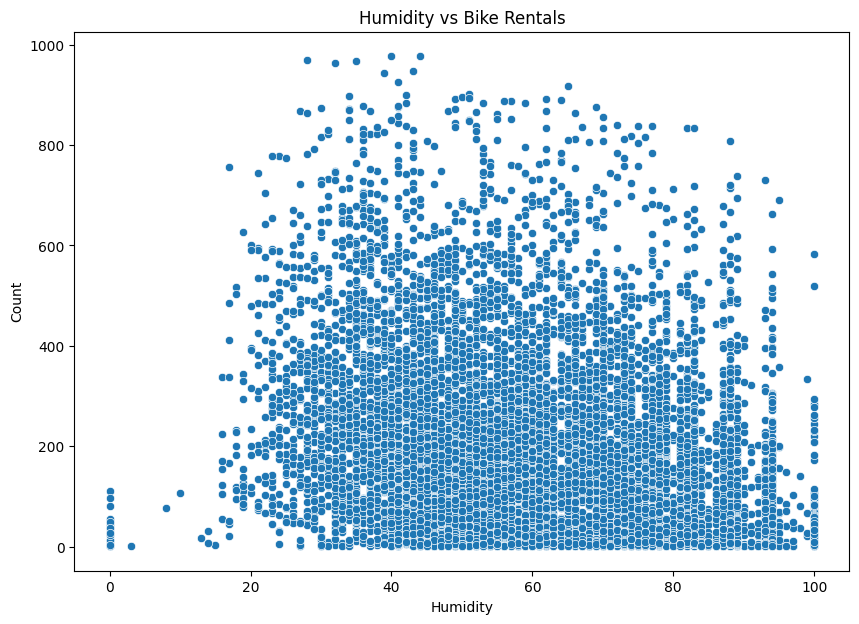

In [10]:
plt.figure(figsize=(10,7))

sb.scatterplot(x='humidity', y='count', data=train)

plt.title("Humidity vs Bike Rentals")
plt.xlabel("Humidity")
plt.ylabel("Count")

plt.show()

**2. Relationship of Humidity with Count**

a) Bike Rentals are extremely low when the humidty is extremely low.

b) Bike Rentals are fairly on the lower side when the humidity is extremely high.

b) Bike rentals are high during comfortable humidity between 25-80.

c) Relationship is not linear - Bike rentals are not increasing/decreasing linearly with temperature. Variance is also high.

d) Due to above reasons, Plynomial Regression will be required.

e) We can tell that there is a weak negative relationship but its not linear and data has high variance. Hence, Humidity alone cannot decide the Bike rental counts.


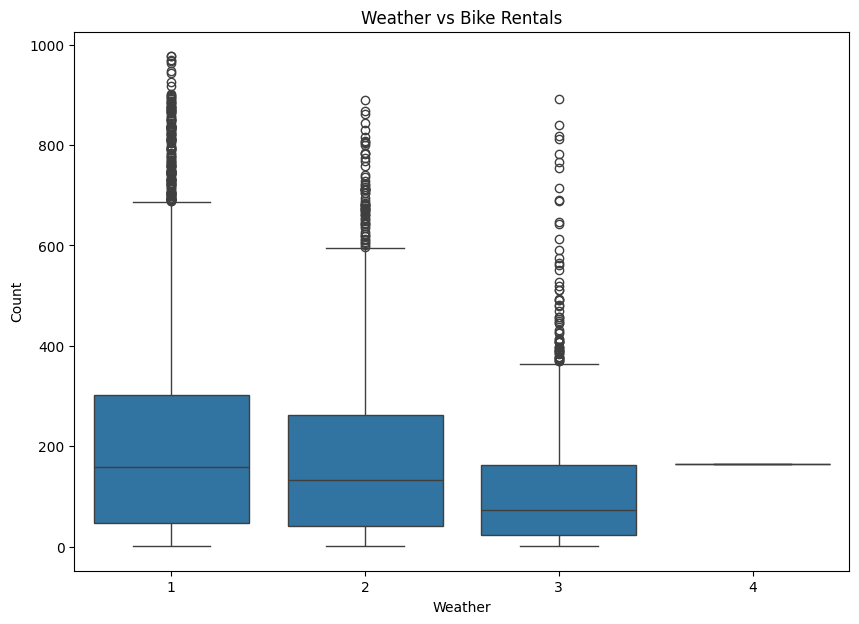

In [11]:
plt.figure(figsize=(10,7))

sb.boxplot(x='weather', y='count', data=train)

plt.title("Weather vs Bike Rentals")
plt.xlabel("Weather")
plt.ylabel("Count")

plt.show()

**3. Relationship of Weather with Count**

a) Bike Rentals are better and more frequent during good weather (weather 1)

b) Bike Rentals are decreasing when the weather value is increasing from 1 to 4. Bad weather leads to lesser bike rentals.


**4. Feature engineering to derive hour from datetime**

Datetime cannot be used in linear regression since its nota numerical value. We need to derive hour from the date time. Also make sure that this hour feature is cyclic.


In [12]:
train['datetime'] = pd.to_datetime(train['datetime'])

train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday

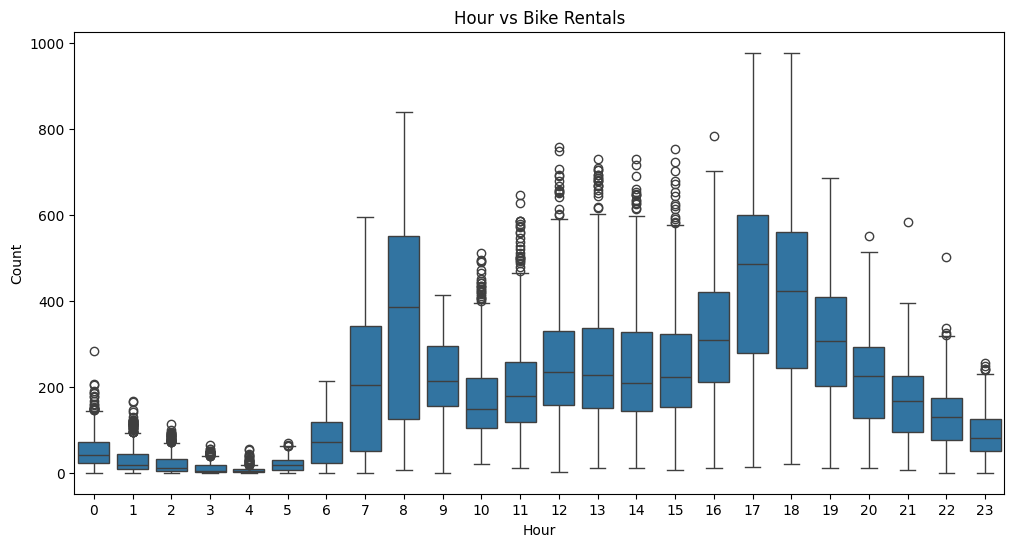

In [13]:
plt.figure(figsize=(12,6))

sb.boxplot(x='hour', y='count', data=train)

plt.title("Hour vs Bike Rentals")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

**5. Relationship of Hour (DateTime) with Count**

a) Bike Rentals are high at Morning time around 8 AM and then it drops a bit. Then it again peaks in the evening time around 5 PM to 6 PM and then goes on decreasing.

b) Bike Rentals are extremely low during early hours before 7 AM and also are on lower side in late hours after 8 PM.

c) The dependency on time is very strong and clear.

d) The bike rentals graph is non-linear with respect to hours hence ploynomial regression will be required.


**Q3. Suggest which variables are likely to be most informative.**

**Key Features:**
1. **Hour** (derived from datetime) - Based on the above boxplot, it was clear that Hour is the most informative feature for Bike Rentals because Bike rentals were high during peak hours - Morning and Evening where commuting is more due to office and school/college hours.

2. **Weather** - Weather also showed relatively strong influence on bike rentals. People reduce the bike usage during bad weathers. Bike rental was clearly high during weather value 1 compared to weather value 4.

3. **Temperature** - Bike rentals reduced during very high and low temperature. It peaked during good temperature range. The graph was non-linear but clearly showed that bikers prefer comfortable temperature ranges for renting.

4. **Humidity** - The dependency of bike rental on humidity was weak based on the scatterplot, but we still saw that bike renters do not prefer very high humidity or very low humidity.

**Other useful features:**

**Working days and Holidays** affect the nature and need of commuting hence affects the Bike rentals.

**Seasons** - Bike demand might be slighlty affected by seasons. Especially during Rainy season, the rentals will be low.

**Features that are not required.**

**Casual and Registered** features will cause data leakage by indirectly revealing the total count information to the Model.

**atemp (apparent temperature)** value is closely related to temperature feature hence it is a correlated feature. We can remove this feature to avoid using corelated features.

**Q4. You can try to derive features from datetime (hour, weekday, month, season), encode
categorical variables, consider transformations to capture nonlinear trends to improve
your model performance. If you do any of these, report it as answer to Q4. It is optional.**

1. Extract useful features such as hour, weekday, month, and year from the datetime column to help the model understand datetime patterns. Hour is the most informative feature for Bike rentals prediction.
2. Apply cyclic transformation on hour feature using sine and cosine encoding because time is cyclic in nature.
3. Remove casual and registered features to avoid data leakage since:count=casual+registered
4. Consider using polynomial transformations to capture nonlinear relationships between features and bike rental count.
5. Consider Ridge and Lasso Regression to reduce overfitting and handle multicollinearity between correlated features such as temp and atemp.

In [14]:
# Lets call Features as x. Remove the features causing correlation and datat leakage.
# Cyclic encoding of Hour.

import numpy as np

train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)

# Add additional flags to help model understand the relationship of feature to target.

train['is_weekend'] = (train['weekday'] >= 5).astype(int)
train['rush_hour'] = train['hour'].isin([7,8,9,17,18,19]).astype(int)


x = train.drop(columns=[
    'count',
    'datetime',
    'casual',
    'registered',
    'hour',
    'atemp',
    'weekday'
])

y = train['count']

In [15]:
# Split the training data into training data and vaidation data. 80% Training data and 20% validation data.

from sklearn.model_selection import train_test_split

x_train, x_validation, y_train, y_validation = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Create Linear Regression model

from sklearn.linear_model import LinearRegression

# Create model
linreg_model = LinearRegression()

# Train model
linreg_model.fit(x_train, y_train)

LinearRegression()

In [17]:
# Model Prediction for validation data.

y_prediction = linreg_model.predict(x_validation)
y_prediction[y_prediction < 0] = 0



In [18]:
# caluclate RMSLE

import numpy as np

def rmsle(y_validation, y_prediction):
    return np.sqrt(
        np.mean(
            (np.log1p(y_prediction) - np.log1p(y_validation)) ** 2
        )
    )

In [19]:
score = rmsle(y_validation, y_prediction)

print("Linear Regression RMSLE:", score)

Linear Regression RMSLE: 1.0804165990928996


**Q5. Split data into training and validation sets and build a simple Linear Regression model.**

[ANSWER]: In the above steps, we split the training data into training and valdiation data. Created a simple linear regression and generated the predictions.
Model was evaulated and RMSLE was calculated.

RMSLE = 1.0804165990928996

In [20]:
# Start Polynomial regression and import the required libraries.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

In [21]:
# Create Polynomial regression Model.

polynomialreg_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

polynomialreg_model.fit(x_train, y_train)

polynomialreg_pred = polynomialreg_model.predict(x_validation)

polynomialreg_pred[polynomialreg_pred < 0] = 0

In [22]:
# Calculate RMSLE

polynomialreg_score = rmsle(y_validation, polynomialreg_pred)

print("Polynomial Regression RMSLE:", polynomialreg_score)

Polynomial Regression RMSLE: 0.8081748058551315


In [23]:
# Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = make_pipeline(
    PolynomialFeatures(degree=3),
    Ridge(alpha=1)
)

ridge_model.fit(x_train, y_train)

ridge_prediction = ridge_model.predict(x_validation)

ridge_prediction[ridge_prediction < 0] = 0

ridge_score = rmsle(y_validation, ridge_prediction)

print("Ridge RMSLE:", ridge_score)

Ridge RMSLE: 0.7982177665067653


In [24]:
# Lasso Regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

lasso_model = make_pipeline(
    PolynomialFeatures(degree=2),
    StandardScaler(),
    Lasso(alpha=1, max_iter=10000)
)

lasso_model.fit(x_train, y_train)

lasso_prediction = lasso_model.predict(x_validation)

lasso_prediction[lasso_prediction < 0] = 0

lasso_score = rmsle(y_validation, lasso_prediction)

print("Lasso RMSLE:", lasso_score)

Lasso RMSLE: 0.9389539223659292


**Q6. Improving Model Performance**

1. Polynomial transformations (degree 3) were applied to capture the non-linear relationship between features and bike rentals.

2. Ridge Regression was applied on polynomial features with degree 3 to reduce overfitting.

3. Lasso Regression were applied on polynomial features with degree 2.
a. I had to reduce degree 2, because Lasso regression model was facing convergence problem due to high number of polynomials.
b. I had to do feature scaling to scale the fetaures to similar range because again Lasso regression model was facing convergence issue.
c. I had to increase Alpha value from 0.01 to 0.1 to increase regularization because Lasso model was facing convergence problem.

4. Derived additional flag features to help Model understand if the day is a weekend and if the hour is a rush hour. This reduced the RMSLE and improved the performance.

Polynomial Regression improved performance by capturing nonlinear patterns, while Ridge and Lasso Regression helped control model complexity through regularization.




**Q7. Summarize all results (of different models tried out) in one table (RMSLE, key
observations).**

| Model                 | RMSLE  | Key Observation                                                                                         |
| --------------------- | ------ | ------------------------------------------------------------------------------------------------------- |
| Linear Regression     | 1.0804 | Simple baseline model with limited ability to capture nonlinear patterns                                |
| Polynomial Regression | 0.8081 | Improved performance by capturing nonlinear relationships between features                              |
| Ridge Regression      | 0.9389 | Achieved best performance by reducing overfitting and handling multicollinearity through regularization |
| Lasso Regression      | 0.7982 | Performed poorly because aggressive feature selection removed important polynomial features             |


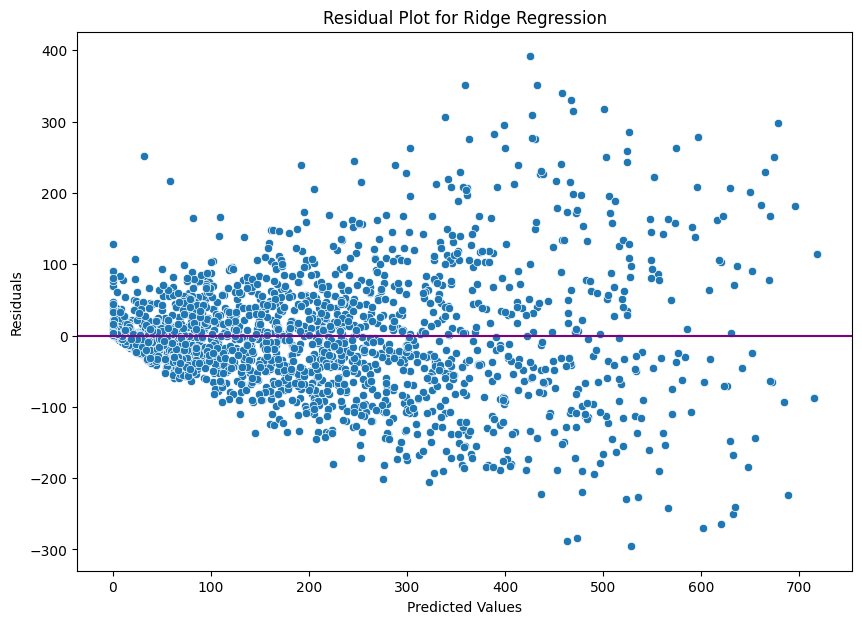

In [25]:
# Residual plot for best perfoming regression model.
residuals = y_validation - ridge_prediction

# Plot
plt.figure(figsize=(10,7))

sb.scatterplot(x=ridge_prediction, y=residuals)

# Horizontal zero line
plt.axhline(y=0, color='purple')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot for Ridge Regression")

plt.show()

**Q8. Plot residuals for the best model.**

In my code, best performing model was Ridge Model.

The residual plot for Ridge Regression shows that most residuals are distributed around the zero line, indicating that the model does not show strong bias in prediction.

However, the spread of residuals increases for higher predicted values.

Overall, Ridge Regression captures a significant portion of the relationship between features and bike rental demand, but some prediction errors still remain due to the complex nature of the data.

**Q9. Explain why the winning model performs better.**

Ridge Regression performed better than the other models because it combined polynomial feature expansion with regularization.

Polynomial features helped the model capture nonlinear relationships between variables such as hour, temperature, humidity, and bike rental count. This improved the model’s ability to learn complex patterns in the data.

At the same time, Ridge regularization reduced overfitting by shrinking large coefficient values. This helped the model generalize better on unseen validation data.

**Q10. Why does RMSLE penalize under-predictions more gently than RMSE?**

1. RMSE directly compares actual and predicted values, hence large prediction errors are heavily penalized.

2. RMSLE first applies logarithmic transformation to both actual and predicted values before calculating error. The logarithm compresses large values. It focuses more on relative differences rather than absolute differences.

3. Because of this, RMSLE penalizes large prediction errors more gently compared to RMSE, especially when the target variable has a wide range of values.

4. RMSLE is therefore more suitable for bike rental prediction because rental counts are highly skewed and vary significantly across different hours and conditions.

**Q11. What are the trade-offs between model simplicity and predictive power?**

Simple models such as Linear Regression are easy to understand and implement.

They train faster and have lower computational complexity, but they may fail to capture complex nonlinear relationships in the data like hours and bike rental count example.

More complex models such as Polynomial Regression can improve predictive power by capturing nonlinear patterns. However, increasing model complexity may lead to overfitting.

Regularization techniques such as Ridge and Lasso Regression help reduce overfitting by controlling model complexity. Ridge shrinks large coefficients, while Lasso can also perform feature selection by removing less important features. However the computational cost increases.

Therefore, there is a trade-off between simplicity and predictive power.
Simpler models are more interpretable, faster and less complex.
while more powerful models generally achieve better predictive performance at the cost of higher complexity and computational cost.


**Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?**

Linear Regression assumes a linear relationship between features and the target variable.

However, real world examples like bike rental demand changes are non linear and cyclic in nature.

Feature engineering techniques such as extracting the hour feature from datetime, cyclic encoding of hour (sine and cosine), and polynomial transformations helps the model to better capture these complex and non linear patterns.

Feature scaling helps in standardizing the features which have large gap in value like Salary is 5 lakh and age is 23. Standardizing these features bring them to the same range so that Model does not give more importance to the feature with large values.

Ridge and Lasso regression helps in regularization to reduce overfitting and complexity of the models.

Hence, linear Regression alone cannot capture time-of-day effects effectively when data is cyclic, periodic and non linear like Bike Rentals example.

In [26]:
# Print best regression model results into CSV file

# Read Test file.
test = pd.read_csv("bike_test.csv")

# Extract hour from datetime.

test['datetime'] = pd.to_datetime(test['datetime'], format = 'mixed')
test['hour'] = test['datetime'].dt.hour
test['weekday'] = test['datetime'].dt.weekday
test['hour_sin'] = np.sin(2 * np.pi * test['hour'] / 24)
test['hour_cos'] = np.cos(2 * np.pi * test['hour'] / 24)
test['is_weekend'] = (train['weekday'] >= 5).astype(int)
test['rush_hour'] = train['hour'].isin([7,8,9,17,18,19]).astype(int)

test.head

# Remove unwanted features
y_test = test.drop(columns=[
    'hour',
    'datetime',
    'atemp',
    'weekday'
])

test_prediction = ridge_model.predict(y_test)

test_prediction[test_prediction < 0] = 0

submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count_predicted': test_prediction
})

submission.to_csv("submission.csv", index=False)

